# Liver Disease Prediction using Machine Learning

## 📌 Problem Statement
Liver disease is a serious health condition that requires early diagnosis for effective treatment.  
The objective of this project is to build a machine learning classification model to predict whether a patient has liver disease based on medical attributes.

In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [187]:
df = pd.read_excel("project-data (1) (1).xlsx")
df.head()

,category,age,sex,albumin,alkaline_phosphatase,alanine_aminotransferase,aspartate_aminotransferase,bilirubin,cholinesterase,cholesterol,creatinina,gamma_glutamyl_transferase,protein
0,no_disease,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,no_disease,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,no_disease,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,no_disease,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,no_disease,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [188]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   category                    615 non-null    object 
 1   age                         615 non-null    int64  
 2   sex                         615 non-null    object 
 3   albumin                     614 non-null    float64
 4   alkaline_phosphatase        597 non-null    float64
 5   alanine_aminotransferase    614 non-null    float64
 6   aspartate_aminotransferase  615 non-null    float64
 7   bilirubin                   615 non-null    float64
 8   cholinesterase              615 non-null    float64
 9   cholesterol                 605 non-null    float64
 10  creatinina                  615 non-null    float64
 11  gamma_glutamyl_transferase  615 non-null    float64
 12  protein                     614 non-null    float64
dtypes: float64(10), int64(1), object(2)

In [189]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)


Missing values per column:
 category                       0
age                            0
sex                            0
albumin                        1
alkaline_phosphatase          18
alanine_aminotransferase       1
aspartate_aminotransferase     0
bilirubin                      0
cholinesterase                 0
cholesterol                   10
creatinina                     0
gamma_glutamyl_transferase     0
protein                        1
dtype: int64


category
no_disease         533
cirrhosis           30
hepatitis           24
fibrosis            21
suspect_disease      7
Name: count, dtype: int64


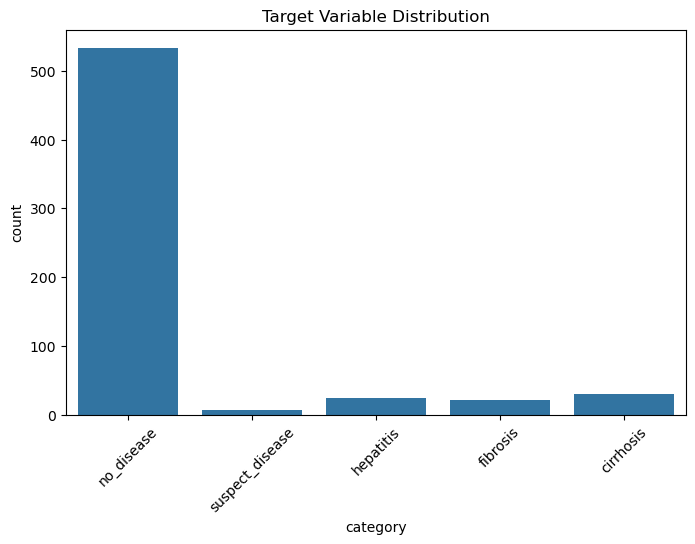

In [190]:
# Target variable distribution
print(df['category'].value_counts())
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='category')
plt.title('Target Variable Distribution')
plt.xticks(rotation=45)
plt.show()



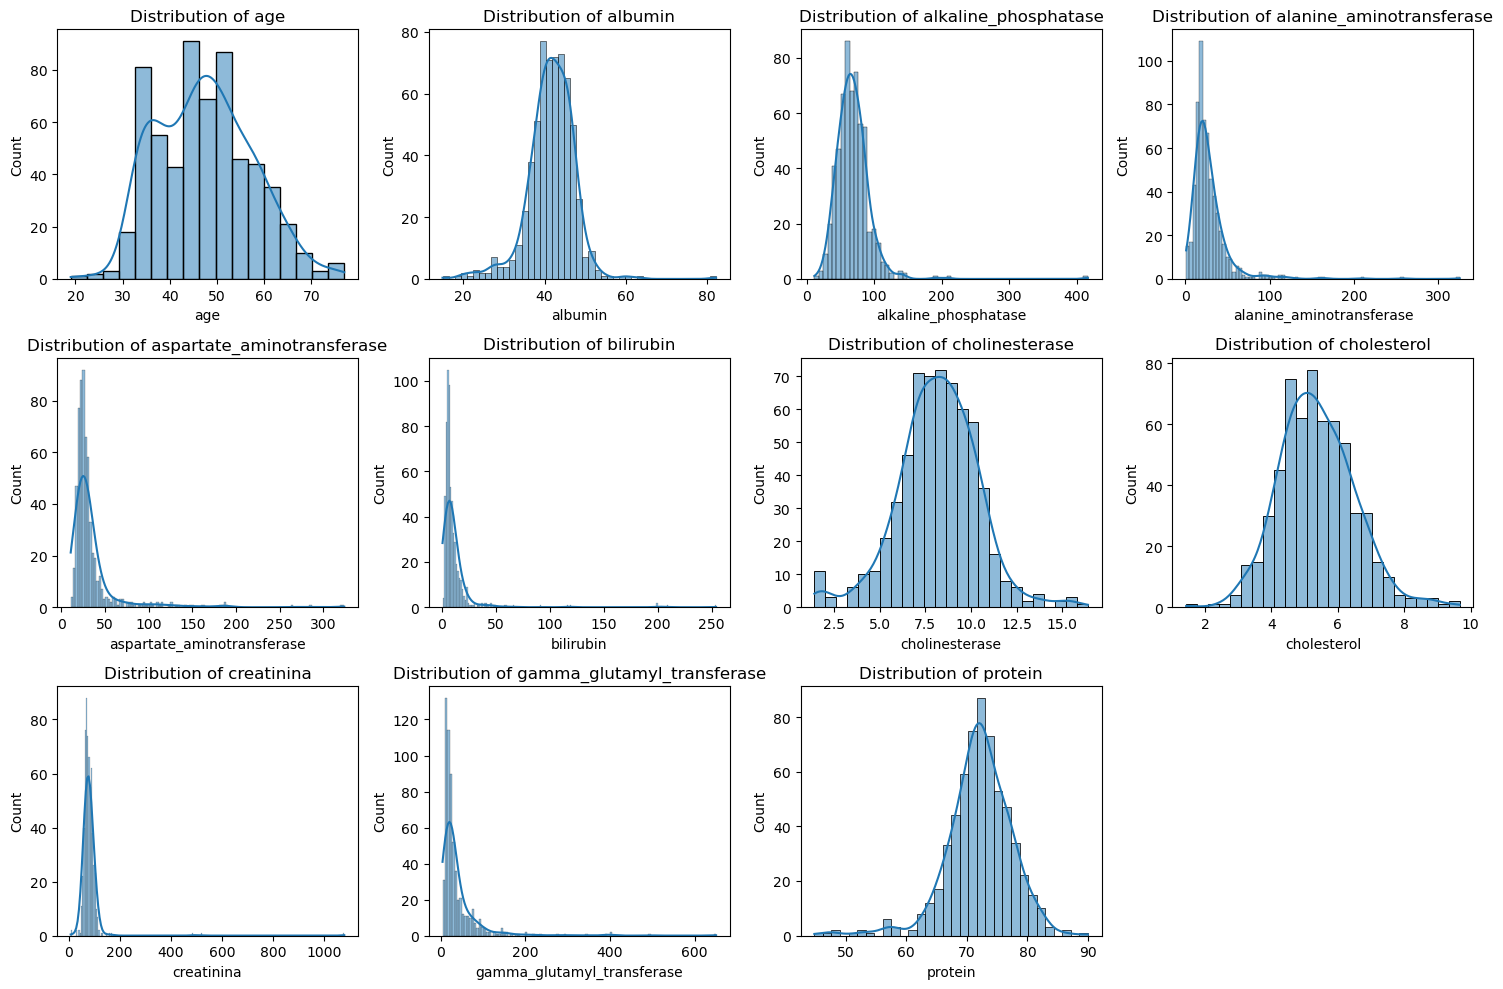

In [191]:
# Numeric feature histograms
numeric_cols = df.select_dtypes(include='number').columns.tolist()
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 4, i+1)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()



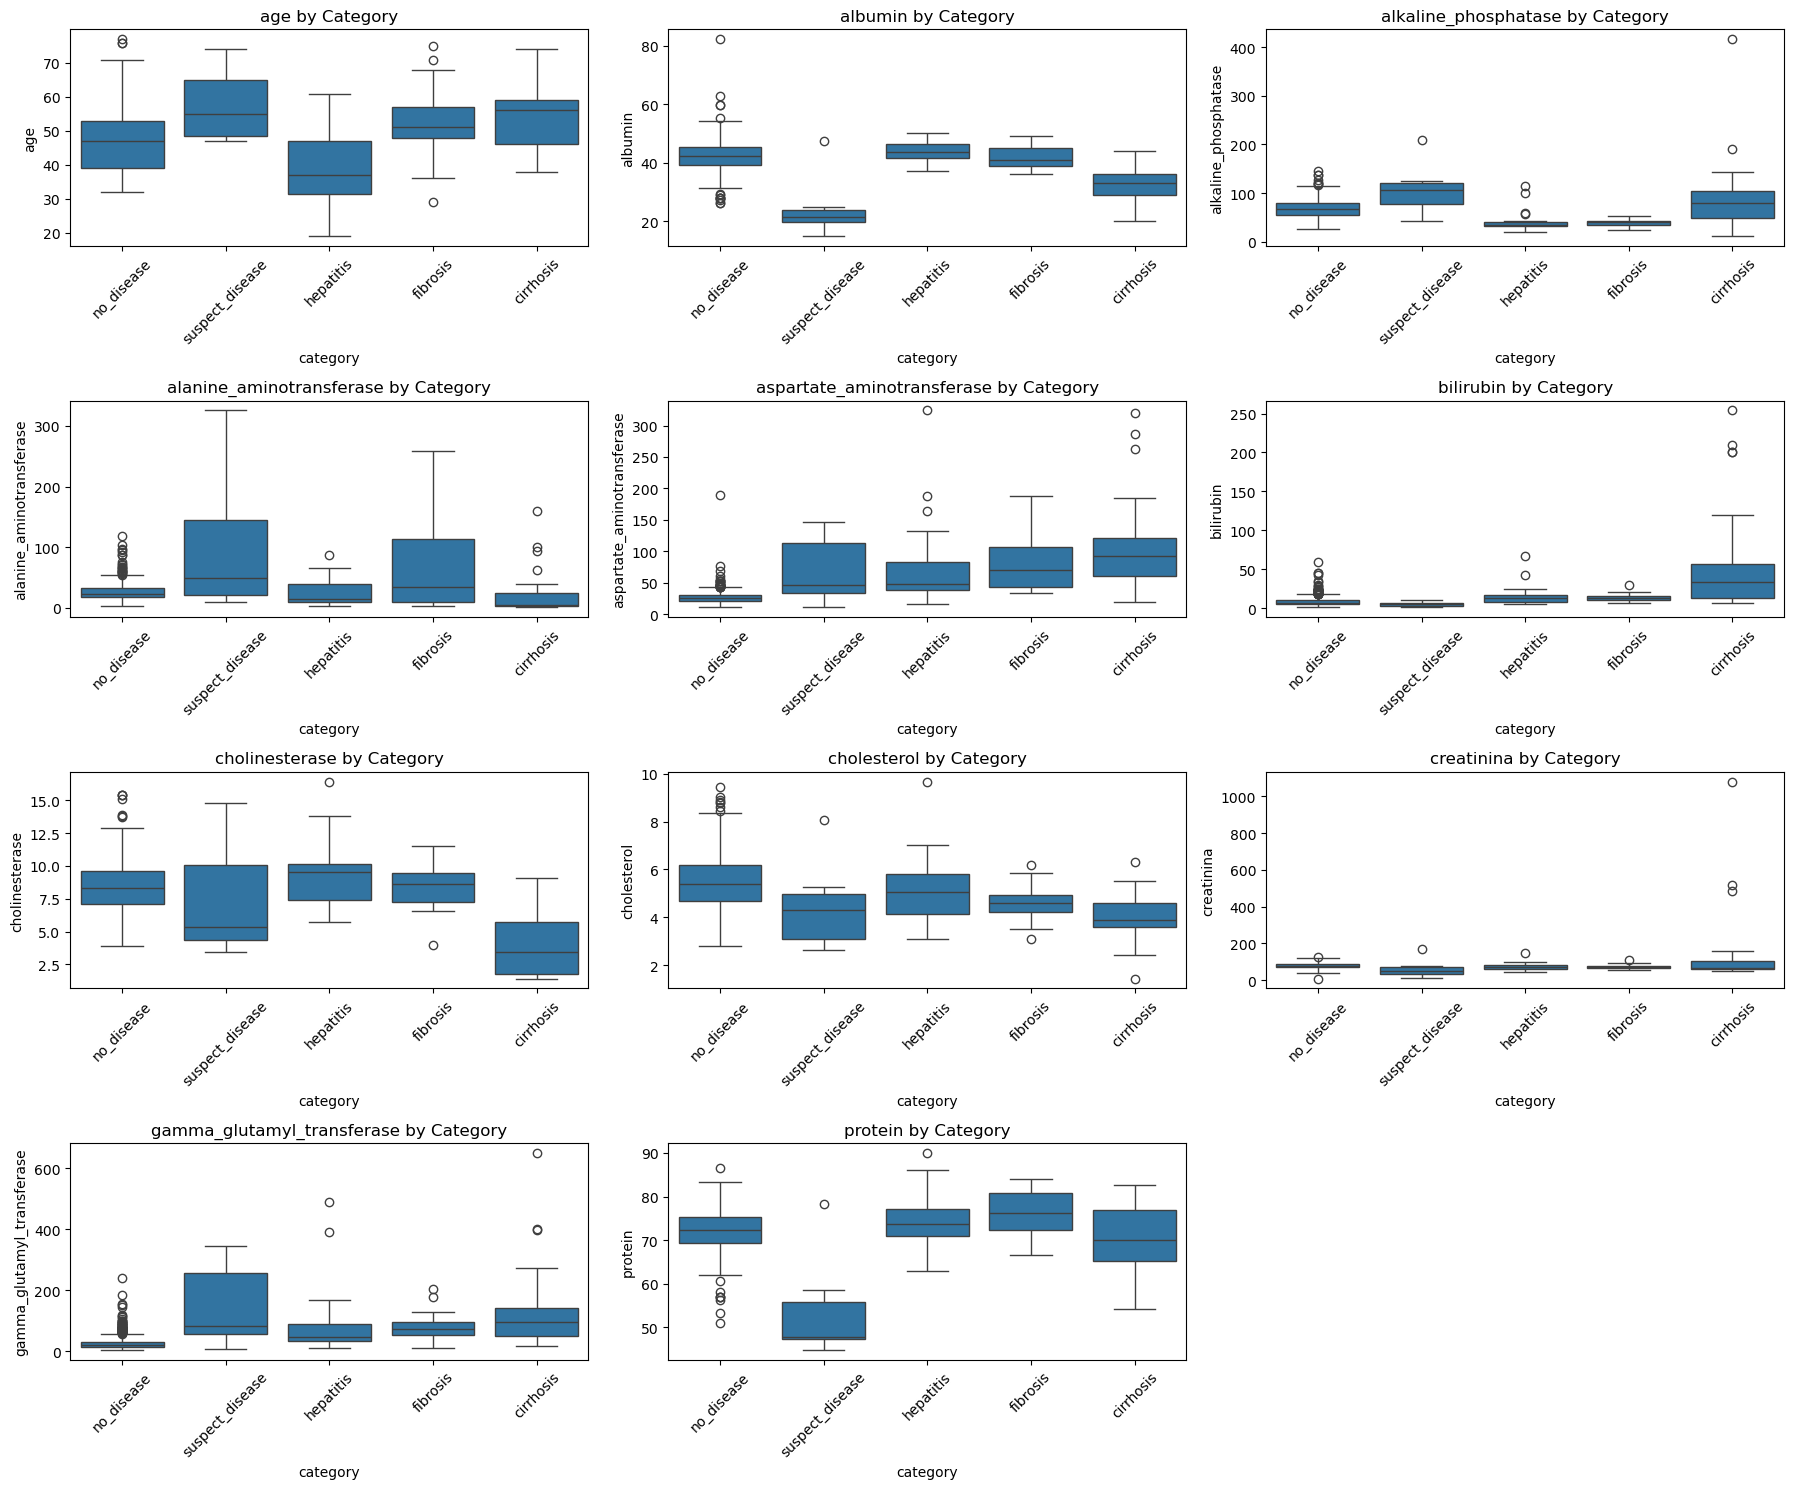

In [192]:
# Boxplots of numeric features by category to check spread and outliers
plt.figure(figsize=(18,15))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 3, i+1)
    sns.boxplot(x='category', y=col, data=df)
    plt.title(f'{col} by Category')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



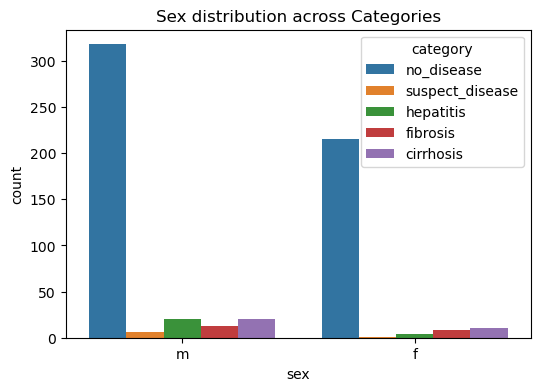

In [193]:
# Sex distribution by category
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sex', hue='category')
plt.title('Sex distribution across Categories')
plt.show()



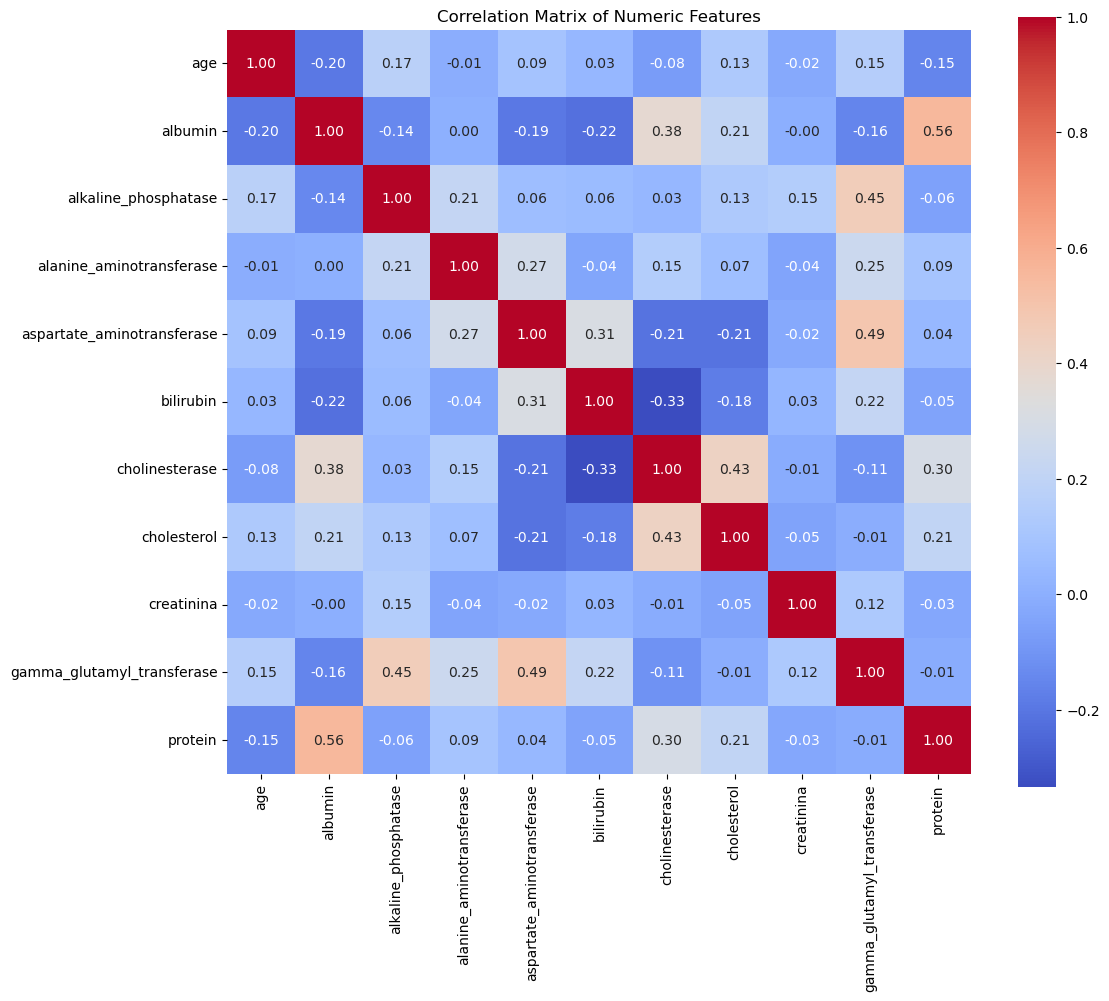

In [194]:
# Correlation matrix of numeric features (exclude non-numeric)
plt.figure(figsize=(12,10))
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.show()


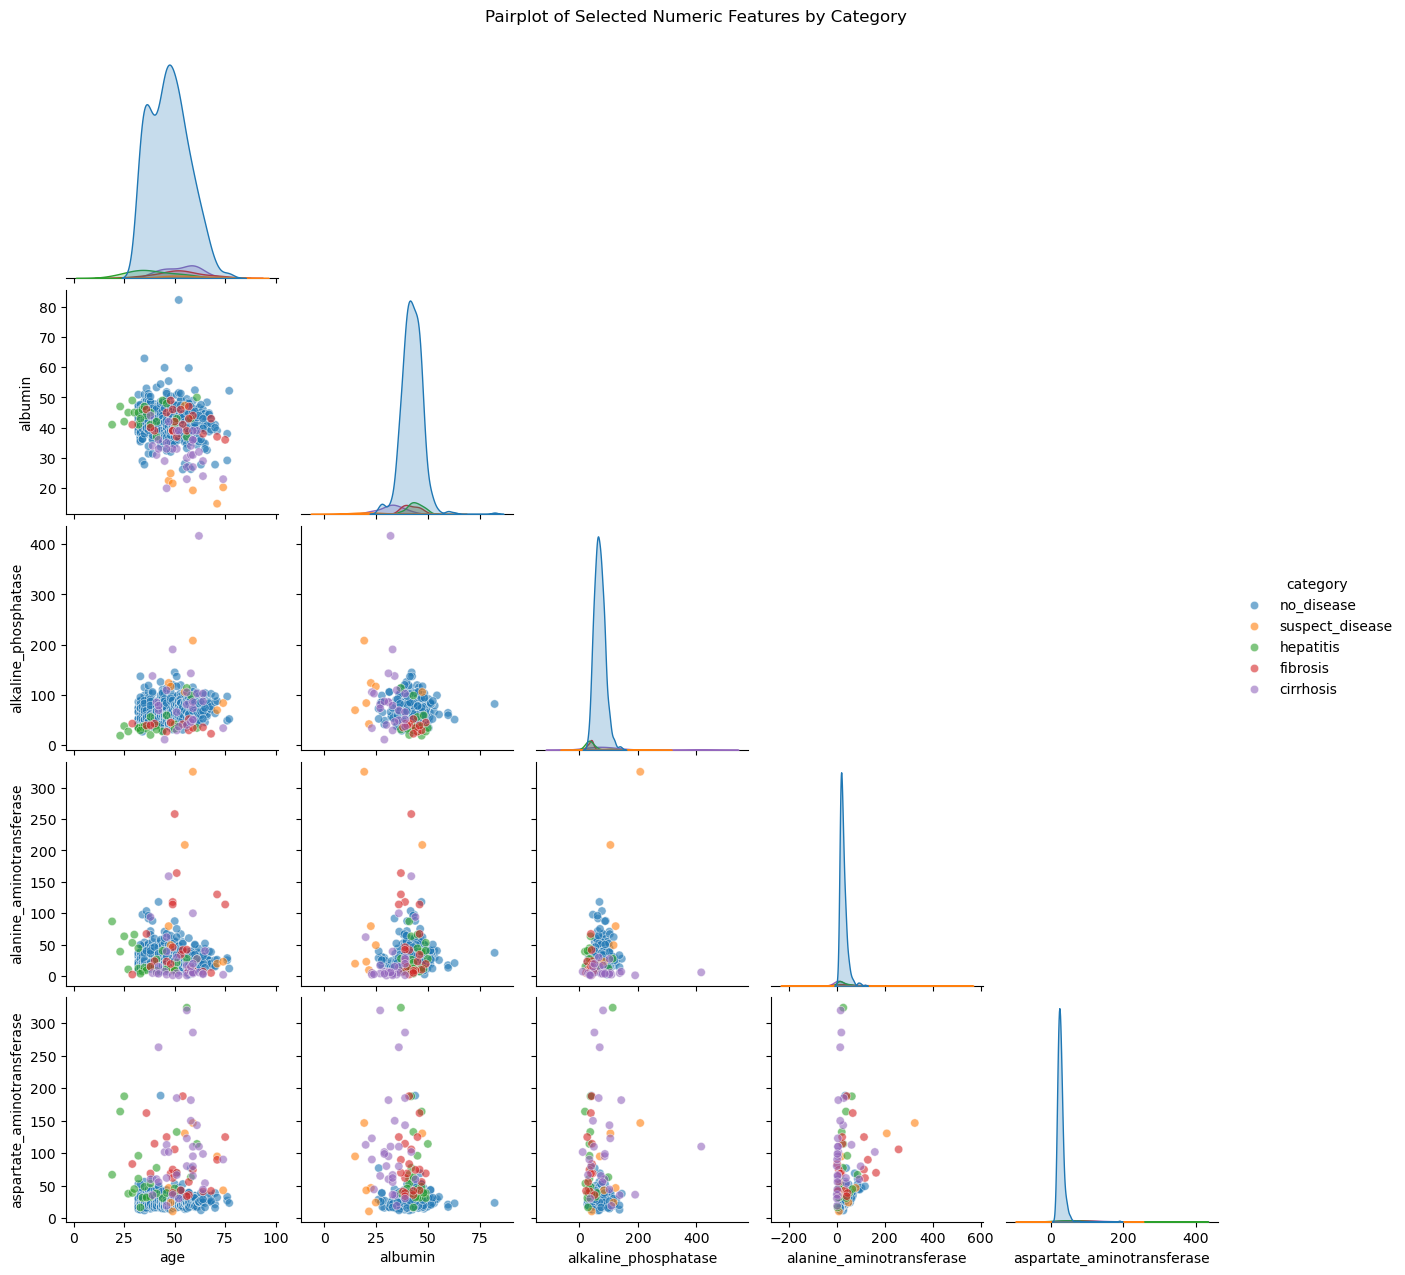

In [195]:
# Pairplot of selected numeric features colored by category
sns.pairplot(df, vars=numeric_cols[:5], hue='category', corner=True, plot_kws={'alpha':0.6})
plt.suptitle('Pairplot of Selected Numeric Features by Category', y=1.02)
plt.show()



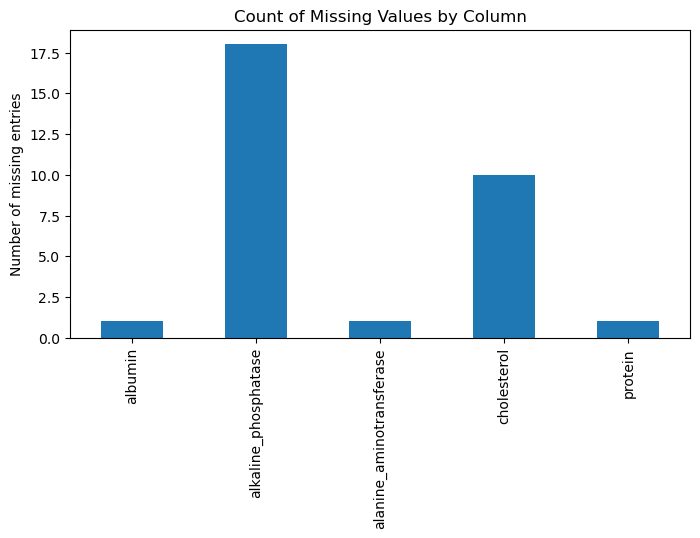

In [196]:
# Visualizing missing values count
missing = df.isnull().sum()
missing = missing[missing > 0]
plt.figure(figsize=(8,4))
missing.plot(kind='bar')
plt.title('Count of Missing Values by Column')
plt.ylabel('Number of missing entries')
plt.show()




In [197]:
# Simple missing value imputation with median for numeric features
for col in numeric_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

if df['sex'].isnull().sum() > 0:
    df['sex'].fillna(df['sex'].mode()[0], inplace=True)

print("Missing values after imputation:\n", df.isnull().sum())



Missing values after imputation:
 category                      0
age                           0
sex                           0
albumin                       0
alkaline_phosphatase          0
alanine_aminotransferase      0
aspartate_aminotransferase    0
bilirubin                     0
cholinesterase                0
cholesterol                   0
creatinina                    0
gamma_glutamyl_transferase    0
protein                       0
dtype: int64


C:\Users\TEJAS\AppData\Local\Temp\ipykernel_19436\3971516841.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


In [198]:
# Outlier treatment using IQR capping method
def treat_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))
    return df

for col in numeric_cols:
    df = treat_outliers_iqr(df, col)

print("Summary statistics after outlier treatment:")
df.describe().transpose()



Summary statistics after outlier treatment:


,count,mean,std,min,25%,50%,75%,max
age,615.0,47.407317,10.052729,19.0000,39.000,47.00,54.000,76.5000
albumin,615.0,41.703008,4.987365,29.2000,38.800,41.95,45.200,54.8000
alkaline_phosphatase,615.0,67.283984,19.779375,13.4250,52.950,66.20,79.300,118.8250
alanine_aminotransferase,615.0,25.860163,13.500313,0.9000,16.400,23.00,33.050,58.0250
aspartate_aminotransferase,615.0,28.668130,9.938424,10.6000,21.600,25.90,32.900,49.8500
bilirubin,615.0,8.879431,5.028590,0.8000,5.300,7.30,11.200,20.0500
cholinesterase,615.0,8.202309,2.079430,2.9525,6.935,8.26,9.590,13.5725
cholesterol,615.0,5.358667,1.087706,2.4675,4.620,5.30,6.055,8.2075
creatinina,615.0,78.356748,15.363140,35.5000,67.000,77.00,88.000,119.5000
gamma_glutamyl_transferase,615.0,31.590163,21.591212,4.5000,15.700,23.30,40.200,76.9500


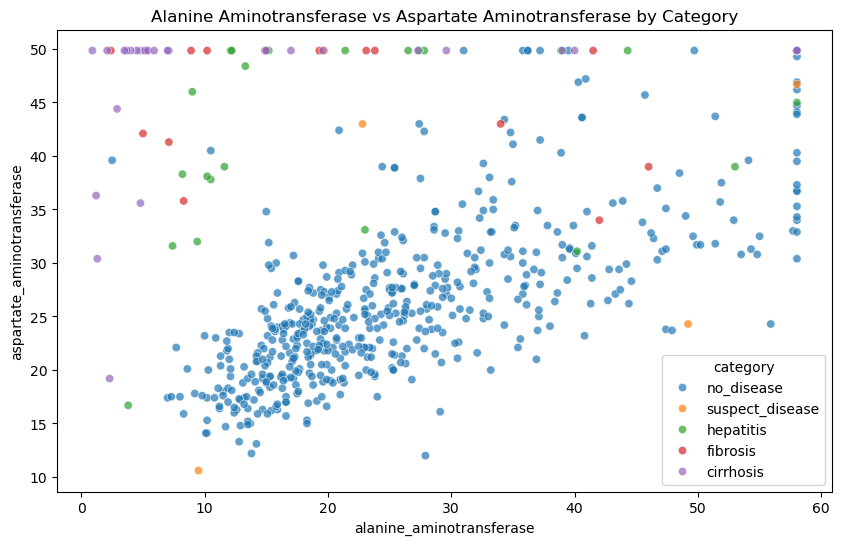

In [199]:
# Scatter plot of key liver enzyme features post outlier treatment
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='alanine_aminotransferase', y='aspartate_aminotransferase', hue='category', alpha=0.7)
plt.title('Alanine Aminotransferase vs Aspartate Aminotransferase by Category')
plt.show()



In [200]:
def treat_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))
    return df

# Apply outlier treatment to all numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()

for column in numeric_cols:
    df = treat_outliers_iqr(df, column)


## 📌 EDA Conclusion

From the exploratory data analysis, we observed that the dataset contains class imbalance between liver disease and non-liver disease patients. Several numerical features show skewed distributions and the presence of outliers.

Correlation analysis indicates that some medical features are strongly related to each other, especially bilirubin and enzyme-related attributes. Boxplots suggest that certain features show noticeable differences between the two target classes, indicating their importance for prediction.

Overall, the dataset contains meaningful patterns suitable for building a classification model. However, proper preprocessing, feature scaling, and handling of class imbalance are necessary to improve model performance.

# Model Building


In [201]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import joblib

In [202]:
df = pd.read_excel("project-data (1) (1).xlsx")

df = df.drop_duplicates()
df = df.dropna()

In [203]:
# Encode categorical columns: target 'category' & feature 'sex'
from sklearn.preprocessing import LabelEncoder

category_encoder = LabelEncoder()
sex_encoder = LabelEncoder()

df['category'] = category_encoder.fit_transform(df['category'])
df['sex'] = sex_encoder.fit_transform(df['sex'])


In [204]:
# -------------------------------
# Define Features and Target
# -------------------------------

X = df.drop("category", axis=1)
y = df["category"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature Order Used For Training:")
print(X.columns)

Feature shape: (589, 12)
Target shape: (589,)

Feature Order Used For Training:
Index(['age', 'sex', 'albumin', 'alkaline_phosphatase',
       'alanine_aminotransferase', 'aspartate_aminotransferase', 'bilirubin',
       'cholinesterase', 'cholesterol', 'creatinina',
       'gamma_glutamyl_transferase', 'protein'],
      dtype='object')


In [205]:
# Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [206]:
# -------------------------------
# Feature Scaling
# -------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling completed.")

Scaling completed.


In [207]:
# Initialize and train models
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    
    results.append([name, acc])
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.9662
Random Forest Accuracy: 0.9459
SVM Accuracy: 0.9324
KNN Accuracy: 0.9189


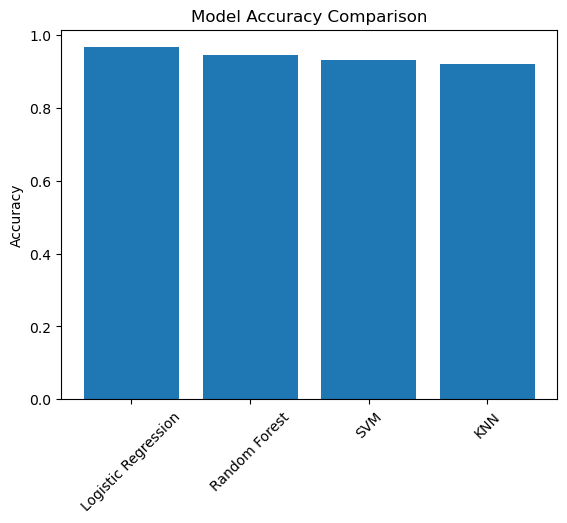

In [208]:
#Accuracy Comparison Chart
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


Confusion Matrix for Logistic Regression


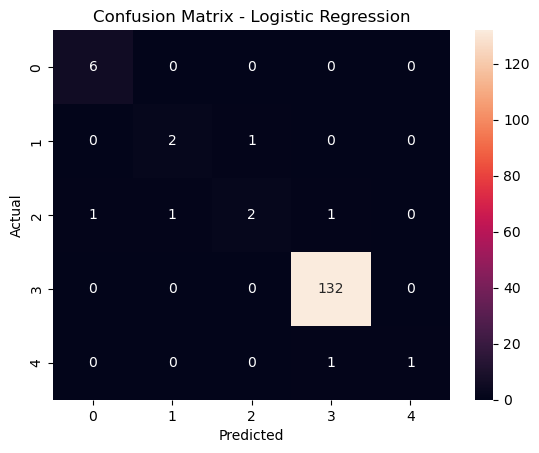


Confusion Matrix for Random Forest


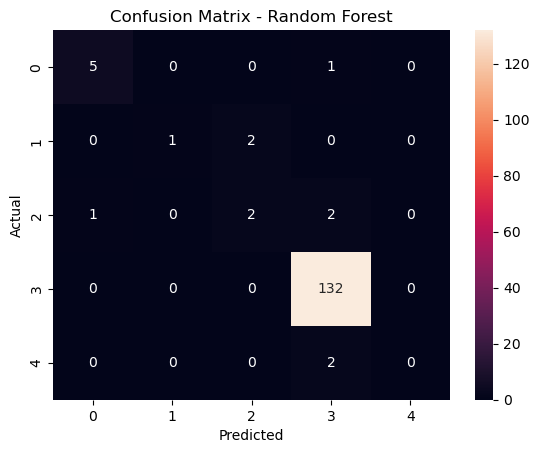


Confusion Matrix for SVM


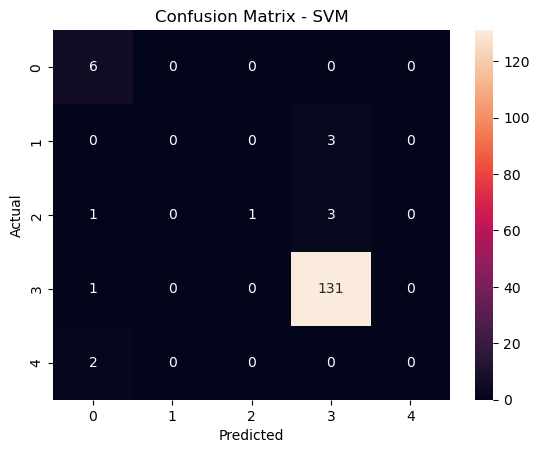


Confusion Matrix for KNN


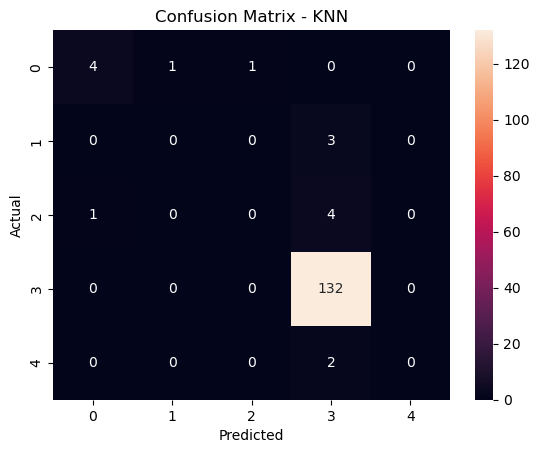

In [209]:
#Confusion Matrix for Each Model
for name in models.keys():
    
    print(f"\nConfusion Matrix for {name}")
    
    cm = confusion_matrix(y_test, predictions[name])
    
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [210]:
# Select best model
best_model = models["Logistic Regression"]

# Save model
joblib.dump(best_model, "model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save label encoder
joblib.dump(category_encoder, "label_encoder.pkl")

print("Model, Scaler, and Label Encoder saved successfully.")

Model, Scaler, and Label Encoder saved successfully.


Conclusion

In this project, a multi class liver disease prediction system was developed using machine learning techniques. The dataset was carefully preprocessed by handling missing values, encoding categorical features, and applying feature scaling to ensure stable model performance.

Several classification algorithms including Logistic Regression, Random Forest, Support Vector Machine, and K Nearest Neighbors were trained and evaluated. After comparing their performance on the test dataset, Logistic Regression achieved the highest accuracy of 96.62 percent and was selected as the final model.

The selected model was saved along with the trained scaler and deployed using a Streamlit web application. The application allows users to enter patient details and receive predictions instantly. The model applies the same preprocessing and scaling logic used during training to ensure consistent and reliable predictions.

This project demonstrates a complete end to end machine learning pipeline, covering data preprocessing, model training, evaluation, model selection, and real time deployment. It reflects a strong understanding of building and deploying practical machine learning solutions.